In [ ]:
!pip install --upgrade tensorflow # Update to the latest TensorFlow version
!pip install --upgrade keras

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
!pip install lightgbm
import lightgbm as lgb
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from scipy.stats import shapiro
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
!pip install xgboost # Install xgboost
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import IsolationForest
from scipy.stats import genextreme
from sklearn.pipeline import Pipeline
from tensorflow.keras.layers import Conv2D, Dropout, Input, Flatten, Dense, Reshape, BatchNormalization
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Activation, Embedding, LSTM,MaxPool2D, Dropout, Conv1D, MaxPooling1D, LSTM, concatenate
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.initializers import GlorotUniform
import tensorflow as tf
import os
import random as python_random

!pip install imblearn
from imblearn.over_sampling import SMOTE
import time

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 619.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 6.5 MB/s eta 0:00:00


In [ ]:
def random_seed_function(seed = 345):
  # Set random seed for numpy
  np.random.seed(seed)
  # Set random seed for python
  python_random.seed(seed)
  # Set random seed for tensorflow
  tf.random.set_seed(seed)
  # Set environment variable for reproducibility
  os.environ['TF_DETERMINISTIC_OPS'] = '1'
  # GPU service
  os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CICDDOs2019 Dataset.csv')

### **DATA PREPROCESSING**

In [ ]:
df.head()

,unnamed: 0,flow_id,source_ip,source_port,destination_ip,destination_port,protocol,timestamp,flow_duration,total _fwd_packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,label
0,17594,172.16.0.5-192.168.50.4-901-38627-17,172.16.0.5,901,192.168.50.4,38627,17,09:00.6,1,2,...,0.0,0,0,0.0,0.0,0,0,0,1,NetBIOS
1,51179,172.16.0.5-192.168.50.4-605-63920-17,172.16.0.5,605,192.168.50.4,63920,17,09:00.7,48,2,...,0.0,0,0,0.0,0.0,0,0,0,1,NetBIOS
2,89079,172.16.0.5-192.168.50.4-645-49297-17,172.16.0.5,645,192.168.50.4,49297,17,09:00.7,2,2,...,0.0,0,0,0.0,0.0,0,0,0,1,NetBIOS
3,164090,172.16.0.5-192.168.50.4-894-45406-17,172.16.0.5,894,192.168.50.4,45406,17,09:00.7,46,2,...,0.0,0,0,0.0,0.0,0,0,0,1,NetBIOS
4,36543,172.16.0.5-192.168.50.4-579-58521-17,172.16.0.5,579,192.168.50.4,58521,17,09:00.8,1,2,...,0.0,0,0,0.0,0.0,0,0,0,1,NetBIOS


In [ ]:
df.tail()

,unnamed: 0,flow_id,source_ip,source_port,destination_ip,destination_port,protocol,timestamp,flow_duration,total _fwd_packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,label
299995,316978,172.16.0.5-192.168.50.1-64430-34702-6,172.16.0.5,64430,192.168.50.1,34702,6,30:30.5,102,2,...,0.0,0,0,0.0,0.0,0,0,0,1,UDP-lag
299996,18004,172.16.0.5-192.168.50.1-65110-18353-6,172.16.0.5,65110,192.168.50.1,18353,6,30:30.7,53,2,...,0.0,0,0,0.0,0.0,0,0,0,1,UDP-lag
299997,198851,172.16.0.5-192.168.50.1-65235-12686-6,172.16.0.5,65235,192.168.50.1,12686,6,30:30.7,1,2,...,0.0,0,0,0.0,0.0,0,0,0,1,UDP-lag
299998,284404,172.16.0.5-192.168.50.1-65435-14518-6,172.16.0.5,65435,192.168.50.1,14518,6,30:30.7,49,2,...,0.0,0,0,0.0,0.0,0,0,0,1,UDP-lag
299999,276823,172.16.0.5-192.168.50.1-60487-60838-6,172.16.0.5,60487,192.168.50.1,60838,6,30:30.7,1,2,...,0.0,0,0,0.0,0.0,0,0,0,1,UDP-lag


In [ ]:
# prompt: turn this  299999  to 80000

# Reduce the number of rows in the dataframe to 80000
df = df.sample(n=80000, random_state=42)


In [ ]:
# Get total number of rows
total_rows = df.shape[0]

print("Total number of rows:", total_rows)

Total number of rows: 80000


In [ ]:
df.duplicated().sum().sum()

np.int64(0)

In [ ]:
df.isnull().sum().sum()

np.int64(292)

In [ ]:
df = df.fillna(df.mean(numeric_only=True))   # Fill numeric NaNs with column mean

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df[[' flow_id', ' source_ip', ' destination_ip', ' timestamp',' label', 'SimillarHTTP']] = df[[' flow_id', ' source_ip',' destination_ip', ' timestamp', ' label', 'SimillarHTTP']].apply(lambda col: le.fit_transform(col.astype(str)))


In [ ]:
def Auto_Normalization(df):
    stat, p = shapiro(df)
    print('Statistics=%.3f, p=%.3f' % (stat, p))
    # interpret
    alpha = 0.05
    numeric_features = df.drop([' label'],axis = 1).dtypes[df.dtypes != 'object'].index

    # The selection strategy is based on the following article:
    # https://medium.com/@kumarvaishnav17/standardization-vs-normalization-in-machine-learning-3e132a19c8bf
    # Check if the data distribution follows a Gaussian/normal distribution
    # If so, select the Z-score normalization method; otherwise, select the min-max normalization
    # Details are in the paper
    if p > alpha:
        print('Sample looks Gaussian (fail to reject H0)')
        df[numeric_features] = df[numeric_features].apply(
            lambda x: (x - x.mean()) / (x.std()))
        print('Z-score normalization is automatically chosen and used')
    else:
        print('Sample does not look Gaussian (reject H0)')
        df[numeric_features] = df[numeric_features].apply(
            lambda x: (x - x.min()) / (x.max()-x.min()))
        print('Min-max normalization is automatically chosen and used')
    return df

In [ ]:
df=Auto_Normalization(df)

Statistics=nan, p=1.000
Sample looks Gaussian (fail to reject H0)
Z-score normalization is automatically chosen and used


In [ ]:
df.head()

,unnamed: 0,flow_id,source_ip,source_port,destination_ip,destination_port,protocol,timestamp,flow_duration,total _fwd_packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,label
4941,-0.649869,1.272262,-0.042168,-1.182617,0.733421,1.562569,0.330535,-0.668093,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,9
51775,0.173998,0.806296,-0.042168,-0.477647,0.733421,-1.220609,-3.023565,-0.407669,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,13
115253,-0.617943,-0.715715,-0.042168,-1.180340,-0.301589,1.713263,0.330535,-0.456738,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,2
299321,0.690926,-1.232636,-0.042168,0.632049,-0.301589,0.837337,-3.023565,-0.439187,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,16
173570,-0.557874,0.345578,-0.042168,-1.174799,-0.301589,0.388799,0.330535,-0.974495,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,6


In [ ]:
df.isnull().sum().sum()

np.int64(1120000)

In [ ]:
df = df.fillna(0)


In [ ]:
df.head()

,unnamed: 0,flow_id,source_ip,source_port,destination_ip,destination_port,protocol,timestamp,flow_duration,total _fwd_packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,label
4941,-0.649869,1.272262,-0.042168,-1.182617,0.733421,1.562569,0.330535,-0.668093,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,9
51775,0.173998,0.806296,-0.042168,-0.477647,0.733421,-1.220609,-3.023565,-0.407669,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,13
115253,-0.617943,-0.715715,-0.042168,-1.180340,-0.301589,1.713263,0.330535,-0.456738,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,2
299321,0.690926,-1.232636,-0.042168,0.632049,-0.301589,0.837337,-3.023565,-0.439187,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,16
173570,-0.557874,0.345578,-0.042168,-1.174799,-0.301589,0.388799,0.330535,-0.974495,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,6


In [ ]:
X = df.drop([' label'],axis=1)
y = df[' label']

# Here we used the 80%/20% split, it can be changed based on specific tasks
#X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, shuffle=False,random_state = 0)
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2,random_state = 0)

In [ ]:
df.isnull().sum().sort_values(ascending=False)


,0
unnamed: 0,0
flow_id,0
source_ip,0
source_port,0
destination_ip,0
...,...
Idle Max,0
Idle Min,0
SimillarHTTP,0
Inbound,0


In [ ]:
pd.Series(y_train).value_counts()

,count
label,
14,18231
13,5818
10,5271
6,4671
1,4613
3,4092
5,3723
15,3554
11,3321


In [ ]:
from imblearn.over_sampling import (RandomOverSampler)
resamp = RandomOverSampler()

In [ ]:
X_train, y_train = resamp.fit_resample(X_train, y_train)

In [ ]:
pd.Series(y_train).value_counts()

,count
label,
10,18231
15,18231
14,18231
3,18231
8,18231
5,18231
1,18231
2,18231
11,18231


In [ ]:
df.head()

,unnamed: 0,flow_id,source_ip,source_port,destination_ip,destination_port,protocol,timestamp,flow_duration,total _fwd_packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,label
4941,-0.649869,1.272262,-0.042168,-1.182617,0.733421,1.562569,0.330535,-0.668093,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,9
51775,0.173998,0.806296,-0.042168,-0.477647,0.733421,-1.220609,-3.023565,-0.407669,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,13
115253,-0.617943,-0.715715,-0.042168,-1.180340,-0.301589,1.713263,0.330535,-0.456738,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,2
299321,0.690926,-1.232636,-0.042168,0.632049,-0.301589,0.837337,-3.023565,-0.439187,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,16
173570,-0.557874,0.345578,-0.042168,-1.174799,-0.301589,0.388799,0.330535,-0.974495,-0.180724,-0.153841,...,-0.028224,-0.028913,-0.010966,-0.096772,-0.079135,-0.096523,-0.090505,-0.009071,0.041569,6


In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((328158, 87), (16000, 87), (328158,), (16000,))

In [ ]:
import time
import warnings
import random as python_random
import tensorflow as tf
import os
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import RandomOverSampler

# Linear Discriminant Analysis (LDA)
# Define and train the LDA model
lda_model = LinearDiscriminantAnalysis()
t1 = time.time()
lda_model.fit(X_train, y_train)
t2 = time.time()
# Make predictions on the test set
predictions_lda = lda_model.predict(X_test)

# Evaluate the LDA model
lda_accuracy = round(accuracy_score(y_test, predictions_lda), 7) * 100
lda_precision = round(precision_score(y_test, predictions_lda, average='weighted'), 7) * 100
lda_recall = round(recall_score(y_test, predictions_lda, average='weighted'), 7) * 100
lda_f1 = round(f1_score(y_test, predictions_lda, average='weighted'), 7) * 100

print("\nAccuracy (LDA): {:.7f}%".format(lda_accuracy))
print("Precision (LDA): {:.7f}%".format(lda_precision))
print("Recall (LDA): {:.7f}%".format(lda_recall))
print("F1-Score (LDA): {:.7f}%".format(lda_f1))
print("Time (LDA): {:.5f}".format((t2 - t1) / len(y_test) * 1000000))


Accuracy (LDA): 69.9062500%
Precision (LDA): 82.8810600%
Recall (LDA): 69.9062500%
F1-Score (LDA): 72.5406600%
Time (LDA): 147.98334


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# ... (previous code for data loading, preprocessing, splitting, etc.) ...

# K-Nearest Neighbors (KNN)
# Define and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5) # You can adjust the number of neighbors (k)
t1 = time.time()
knn_model.fit(X_train, y_train)
t2 = time.time()
# Make predictions on the test set
predictions_knn = knn_model.predict(X_test)
# Evaluate the KNN model
knn_accuracy = round(accuracy_score(y_test, predictions_knn), 7) * 100
knn_precision = round(precision_score(y_test, predictions_knn, average='weighted'), 7) * 100
knn_recall = round(recall_score(y_test, predictions_knn, average='weighted'), 7) * 100
knn_f1 = round(f1_score(y_test, predictions_knn, average='weighted'), 7) * 100

print("\nAccuracy (KNN): {:.7f}%".format(knn_accuracy))
print("Precision (KNN): {:.7f}%".format(knn_precision))
print("Recall (KNN): {:.7f}%".format(knn_recall))
print("F1-Score (KNN): {:.7f}%".format(knn_f1))
print("Time (KNN): {:.5f}".format((t2 - t1) / len(y_test) * 1000000))


Accuracy (KNN): 95.5687500%
Precision (KNN): 95.5951400%
Recall (KNN): 95.5687500%
F1-Score (KNN): 95.5766200%
Time (KNN): 14.91547


In [ ]:
# prompt: xgboost

# Extreme Gradient Boosting (XGBoost)
# Define and train the XGBoost model
t1 = time.time()
xgb_model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(X_train, y_train)
t2 = time.time()
# Make predictions on the test set
predictions_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model
xgb_accuracy = round(accuracy_score(y_test, predictions_xgb), 7) * 100
xgb_precision = round(precision_score(y_test, predictions_xgb, average='weighted'), 7) * 100
xgb_recall = round(recall_score(y_test, predictions_xgb, average='weighted'), 7) * 100
xgb_f1 = round(f1_score(y_test, predictions_xgb, average='weighted'), 7) * 100

print("\nAccuracy (XGBoost): {:.7f}%".format(xgb_accuracy))
print("Precision (XGBoost): {:.7f}%".format(xgb_precision))
print("Recall (XGBoost): {:.7f}%".format(xgb_recall))
print("F1-Score (XGBoost): {:.7f}%".format(xgb_f1))
print("Time (XGBoost): {:.5f}".format((t2 - t1) / len(y_test) * 1000000))



Accuracy (XGBoost): 99.3812500%
Precision (XGBoost): 99.3832500%
Recall (XGBoost): 99.3812500%
F1-Score (XGBoost): 99.3817000%
Time (XGBoost): 904.66425


In [ ]:
# Multi-layer Perceptron (MLP)
# Define and train the MLP model
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', random_state=42, max_iter=300) # Example architecture and parameters
t1 = time.time()
mlp_model.fit(X_train, y_train)
t2 = time.time()
# Make predictions on the test set
predictions_mlp = mlp_model.predict(X_test)

# Evaluate the MLP model
mlp_accuracy = round(accuracy_score(y_test, predictions_mlp), 7) * 100
mlp_precision = round(precision_score(y_test, predictions_mlp, average='weighted'), 7) * 100
mlp_recall = round(recall_score(y_test, predictions_mlp, average='weighted'), 7) * 100
mlp_f1 = round(f1_score(y_test, predictions_mlp, average='weighted'), 7) * 100

print("\nAccuracy (MLP): {:.7f}%".format(mlp_accuracy))
print("Precision (MLP): {:.7f}%".format(mlp_precision))
print("Recall (MLP): {:.7f}%".format(mlp_recall))
print("F1-Score (MLP): {:.7f}%".format(mlp_f1))
print("Time (MLP): {:.5f}".format((t2 - t1) / len(y_test) * 1000000))



Accuracy (MLP): 98.4562500%
Precision (MLP): 98.4958500%
Recall (MLP): 98.4562500%
F1-Score (MLP): 98.4685600%
Time (MLP): 27092.83005


In [ ]:
# prompt: LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

# Reshape data for LSTM (samples, timesteps, features)
# Assuming each row is a timestep and features are the columns
X_train_lstm = np.reshape(X_train.values, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test.values, (X_test.shape[0], 1, X_test.shape[1]))

# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(32))
lstm_model.add(Dropout(0.2))
# The output layer depends on the number of classes in your 'label' column.
# Use 'sigmoid' for binary classification (2 classes) or 'softmax' for multi-class classification.
# Assuming binary classification based on the previous models.
num_classes = len(y_train.unique())
if num_classes == 2:
    lstm_model.add(Dense(1, activation='sigmoid'))
    lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
else:
    lstm_model.add(Dense(num_classes, activation='softmax'))
    lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the LSTM model
t1 = time.time()
# You might need to adjust the number of epochs and batch size
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=64, validation_data=(X_test_lstm, y_test), verbose=1)
t2 = time.time()

# Make predictions on the test set
# For binary classification with sigmoid, threshold at 0.5
if num_classes == 2:
    predictions_lstm_prob = lstm_model.predict(X_test_lstm)
    predictions_lstm = (predictions_lstm_prob > 0.5).astype(int)
else:
    predictions_lstm = np.argmax(lstm_model.predict(X_test_lstm), axis=-1)


# Evaluate the LSTM model
lstm_accuracy = round(accuracy_score(y_test, predictions_lstm), 7) * 100
lstm_precision = round(precision_score(y_test, predictions_lstm, average='weighted'), 7) * 100
lstm_recall = round(recall_score(y_test, predictions_lstm, average='weighted'), 7) * 100
lstm_f1 = round(f1_score(y_test, predictions_lstm, average='weighted'), 7) * 100

print("\nAccuracy (LSTM): {:.7f}%".format(lstm_accuracy))
print("Precision (LSTM): {:.7f}%".format(lstm_precision))
print("Recall (LSTM): {:.7f}%".format(lstm_recall))
print("F1-Score (LSTM): {:.7f}%".format(lstm_f1))
print("Time (LSTM): {:.5f}".format((t2 - t1) / len(y_test) * 1000000))


Epoch 1/10
5128/5128 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.7763 - loss: 0.7193 - val_accuracy: 0.9530 - val_loss: 0.1321
Epoch 2/10
5128/5128 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9564 - loss: 0.1329 - val_accuracy: 0.9676 - val_loss: 0.0889
Epoch 3/10
5128/5128 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9655 - loss: 0.1031 - val_accuracy: 0.9667 - val_loss: 0.0954
Epoch 4/10
5128/5128 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9692 - loss: 0.0914 - val_accuracy: 0.9733 - val_loss: 0.0750
Epoch 5/10
5128/5128 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9734 - loss: 0.0797 - val_accuracy: 0.9758 - val_loss: 0.0686
Epoch 6/10
5128/5128 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9743 - loss: 0.0754 - val_accuracy: 0.9754 - val_loss: 0.0703
Epoch 7/10
5128/5128 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9758 - loss: 0.0707 - val_accuracy: 0.9787 - val_loss: 0.0610
Epoch 8/10
5128/5128 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9775 - loss: 0

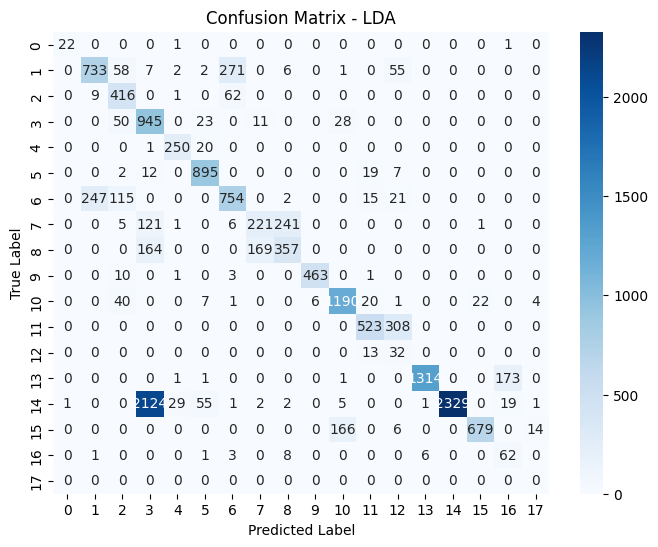

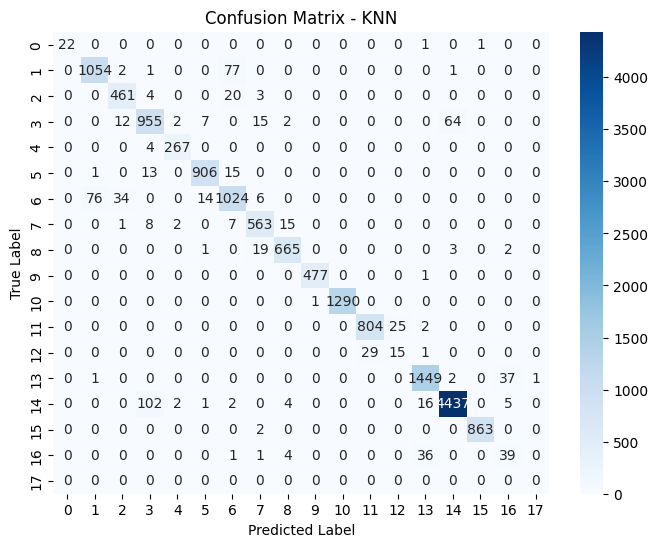

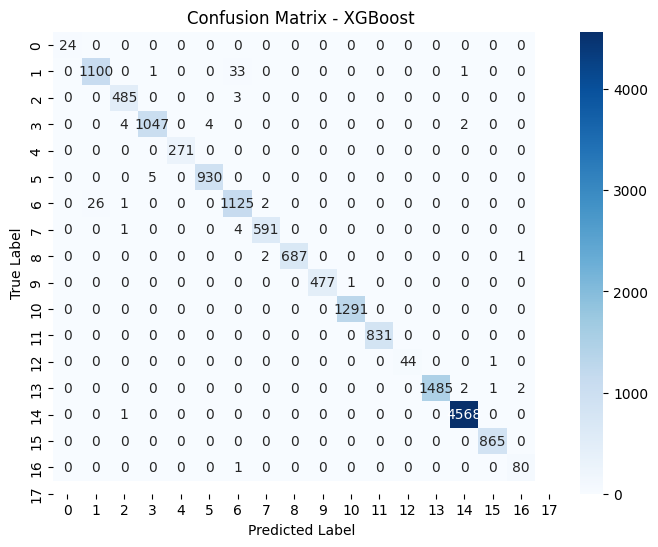

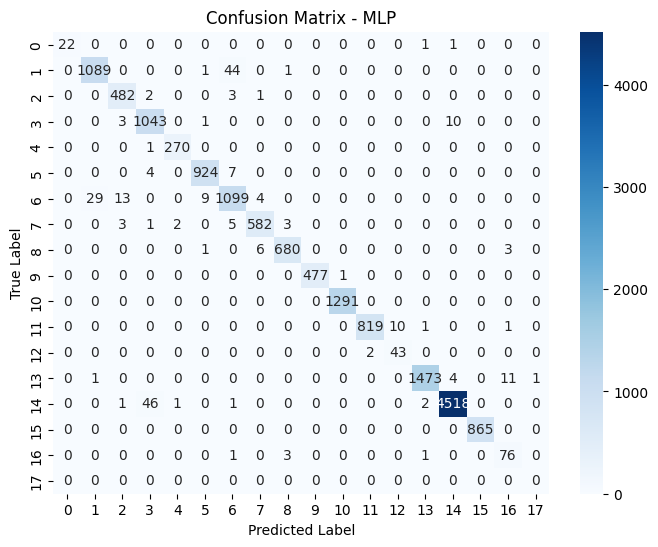

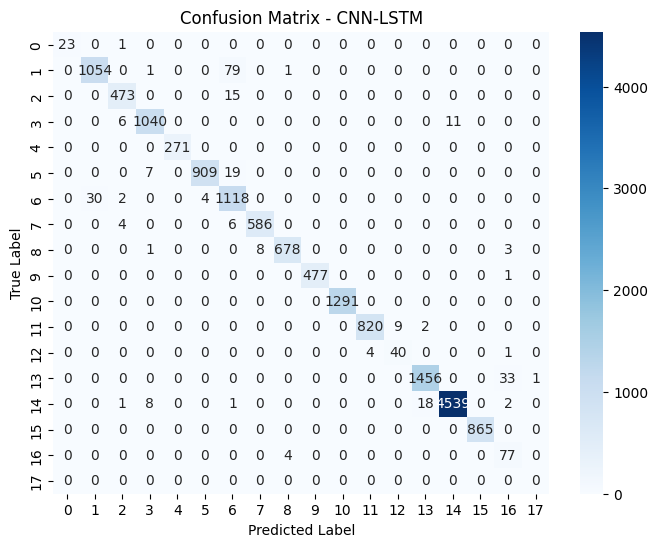

In [ ]:
# prompt: confusion matrix of wholle program in colour firm

import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, model_name, figsize=(8, 6)):
  """
  Plots a confusion matrix with color encoding.

  Args:
    cm (np.ndarray): Confusion matrix.
    classes (list): List of class labels.
    model_name (str): Name of the model for the title.
    figsize (tuple): Figure size.
  """
  plt.figure(figsize=figsize)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
  plt.title(f'Confusion Matrix - {model_name}')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

# Get unique class labels from the training data
unique_classes = np.unique(y_train)
class_labels = [str(label) for label in unique_classes] # Convert labels to string if they are not

# Calculate and plot confusion matrix for each model
models = {
    "LDA": predictions_lda,
    "KNN": predictions_knn,
    "XGBoost": predictions_xgb,
    "MLP": predictions_mlp,
    "CNN-LSTM": predictions_lstm
}

for model_name, predictions in models.items():
  cm = confusion_matrix(y_test, predictions)
  plot_confusion_matrix(cm, class_labels, model_name)


In [ ]:
!pip install tabulate

In [ ]:
# Create a comparison table
data = {
    'Model': ['LDA', 'KNN', 'XGBoost', 'MLP', 'LSTM'],
    'Accuracy (%)': [lda_accuracy, knn_accuracy, xgb_accuracy, mlp_accuracy, lstm_accuracy],
    'Precision (%)': [lda_precision, knn_precision, xgb_precision, mlp_precision, lstm_precision],
    'Recall (%)': [lda_recall, knn_recall, xgb_recall, mlp_recall, lstm_recall],
    'F1-Score (%)': [lda_f1, knn_f1, xgb_f1, mlp_f1, lstm_f1],
}

comparison_df = pd.DataFrame(data)
print("\nModel Comparison Table:")
print(comparison_df.to_markdown(index=False))

# Note: The time calculation `(t2 - t1) / len(y_test) * 1000000` assumes t1 and t2 are the training times for each model.
# To accurately represent inference time, you would need to time the prediction step specifically for each model.
# For example:
# t1_infer = time.time()
# predictions_lda = lda_model.predict(X_test)
# t2_infer = time.time()
# lda_inference_time_us = (t2_infer - t1_infer) / len(y_test) * 1000000
# You would need to perform this timing for each model and use those values in the DataFrame.


Model Comparison Table:
| Model   |   Accuracy (%) |   Precision (%) |   Recall (%) |   F1-Score (%) |
|:--------|---------------:|----------------:|-------------:|---------------:|
| LDA     |        69.9062 |         82.8811 |      69.9062 |        72.5407 |
| KNN     |        95.5688 |         95.5951 |      95.5688 |        95.5766 |
| XGBoost |        99.3812 |         99.3833 |      99.3812 |        99.3817 |
| MLP     |        98.4562 |         98.4958 |      98.4562 |        98.4686 |
| LSTM    |        98.2313 |         98.3581 |      98.2313 |        98.2675 |


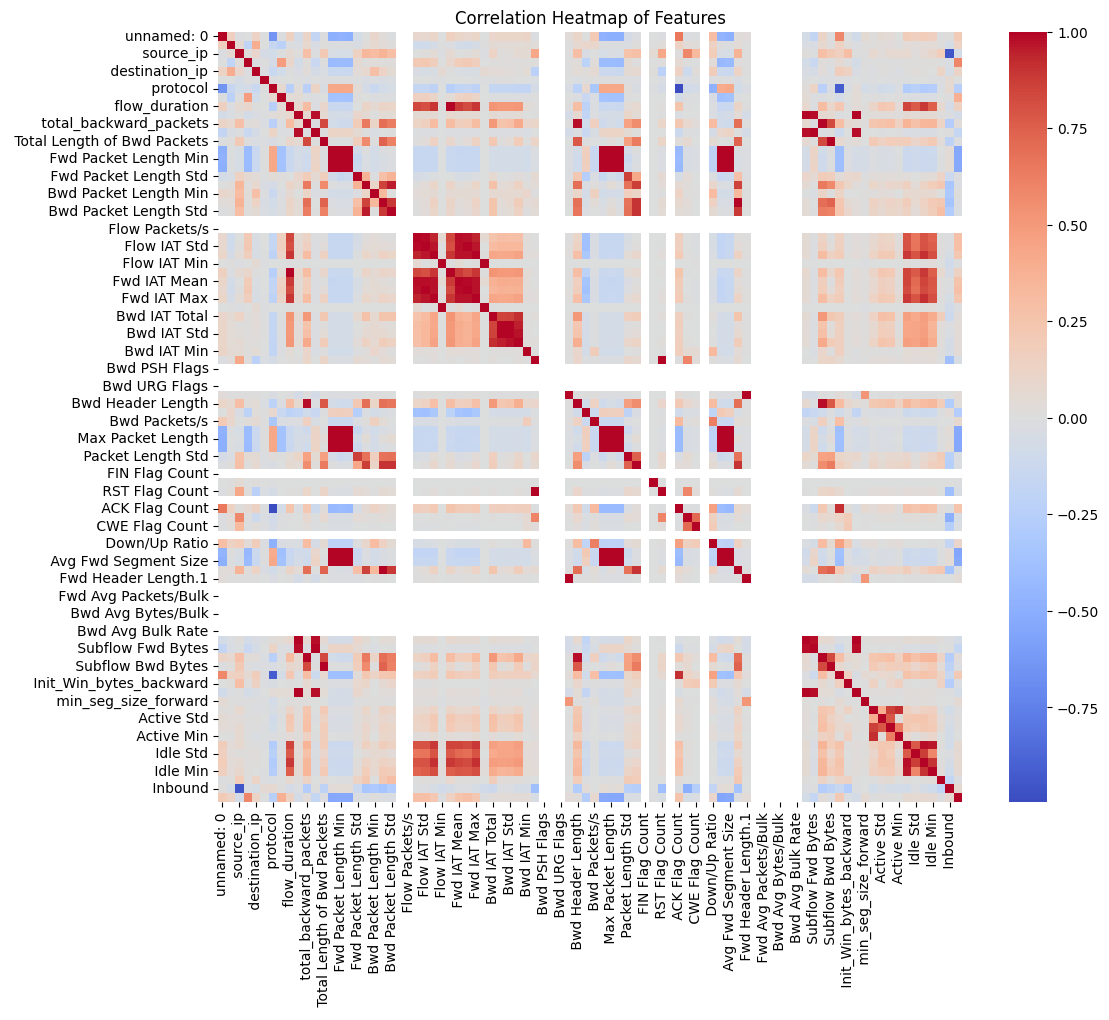

In [ ]:
# prompt: heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

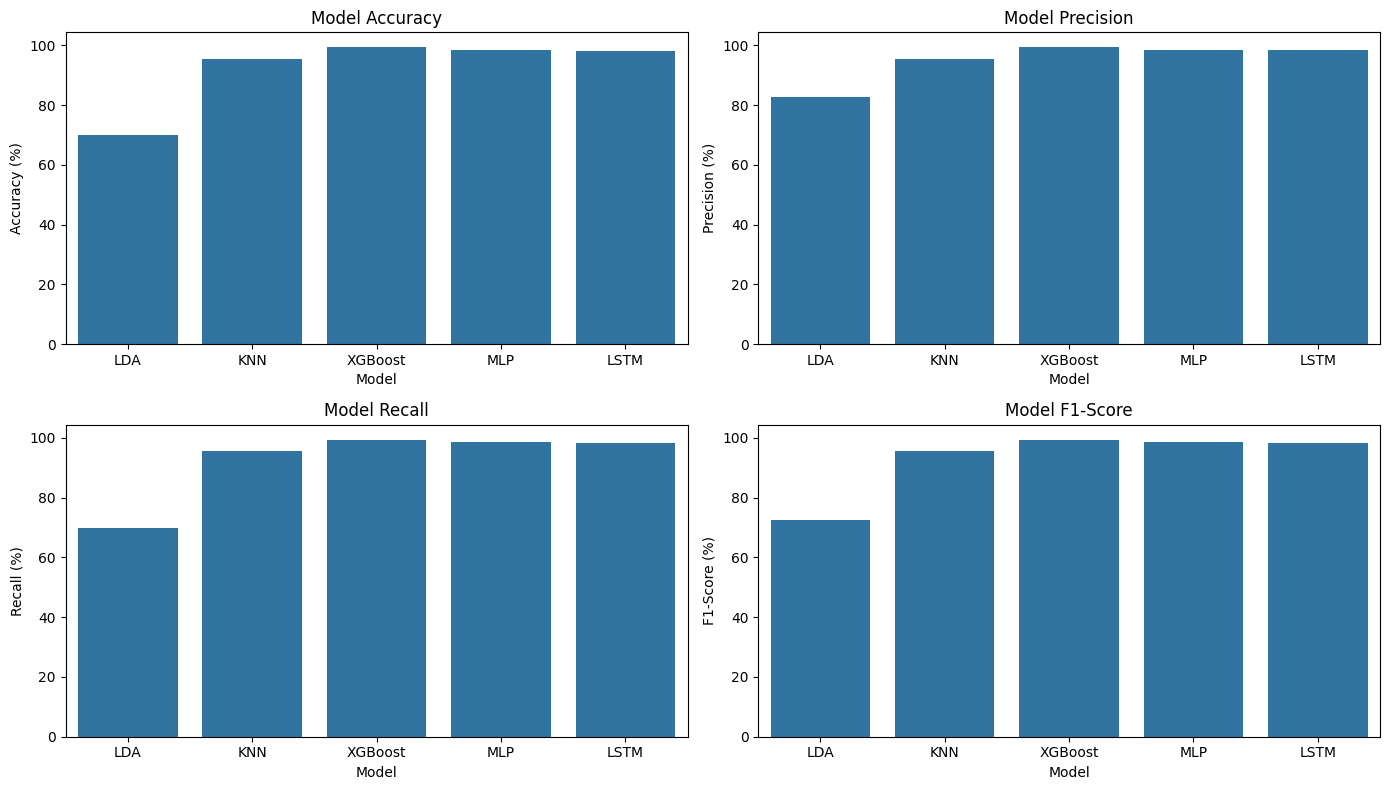

In [ ]:
# prompt: graph

import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
models = comparison_df['Model']
accuracy = comparison_df['Accuracy (%)']
precision = comparison_df['Precision (%)']
recall = comparison_df['Recall (%)']
f1 = comparison_df['F1-Score (%)']

# Plotting performance metrics
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
sns.barplot(x=models, y=accuracy)
plt.title('Model Accuracy')
plt.ylabel('Accuracy (%)')

plt.subplot(2, 2, 2)
sns.barplot(x=models, y=precision)
plt.title('Model Precision')
plt.ylabel('Precision (%)')

plt.subplot(2, 2, 3)
sns.barplot(x=models, y=recall)
plt.title('Model Recall')
plt.ylabel('Recall (%)')

plt.subplot(2, 2, 4)
sns.barplot(x=models, y=f1)
plt.title('Model F1-Score')
plt.ylabel('F1-Score (%)')

plt.tight_layout()
plt.show()


